# 3.1 NumPy
OpenCV에서 이미지는 NumPy 배열로 표현된다.  
이미지 = 3차원 배열 (행 × 열 × 채널)  
- 픽셀 값: 0~255 (uint8)
- 채널: BGR 순서 (OpenCV 기본)

예) 500×500 컬러 이미지 → shape: (500, 500, 3)

In [13]:
import cv2
import numpy as np

img = cv2.imread('../Data/images/doge.jpg')

print(img.dtype)     # uint8
print(img.itemsize)  # 1 (바이트 단위 크기)
print(img.shape)     # (height, width, channels)

uint8
1
(194, 259, 3)


---
## 3.1.2 NumPy 배열 생성 함수

| 함수 | 설명 |
|------|------|
| `np.empty()` | 초기화 없이 배열 생성 (쓰레기값) |
| `np.zeros()` | 0으로 초기화 |
| `np.ones()` | 1로 초기화 |
| `np.full()` | 지정한 값으로 초기화 |
| `np.zeros_like()` | 대상 배열과 같은 shape/dtype, 0으로 초기화 |
| `np.ones_like()` | 대상 배열과 같은 shape/dtype, 1로 초기화 |
| `np.empty_like()` | 대상 배열과 같은 shape/dtype, 초기화 없음 |
| `np.full_like()` | 대상 배열과 같은 shape/dtype, 지정값으로 초기화 |
| `np.arange()` | 순차적인 값 생성 |
| `np.random.rand()` | 0~1 균등분포 난수 |
| `np.random.randn()` | 표준 정규분포 난수 |

---
## 3.1.3 값으로 배열 생성 — np.array()

In [14]:
import numpy as np

# 1차원 배열
a = np.array([1, 2, 3, 4])
print(a)         # [1 2 3 4]
print(a.dtype)   # int64  (정수만 있으면 자동으로 int64)
print(a.shape)   # (4,)

[1 2 3 4]
int64
(4,)


In [15]:
# 2차원 배열 (2행 4열)
b = np.array([[1, 2, 3, 4],
              [5, 6, 7, 8]])
print(b)
print(b.shape)  # (2, 4)

[[1 2 3 4]
 [5 6 7 8]]
(2, 4)


In [16]:
# 정수와 실수 혼합 -> float64 자동 변환
c = np.array([1, 2, 3.14, 4])
print(c)
print(c.dtype)  # float64

[1.   2.   3.14 4.  ]
float64


In [17]:
# dtype 명시적 지정
d = np.array([1, 2, 3., 4.1], dtype=np.float32)
print(d)        # [1.  2.  3.  4.1]
print(d.dtype)  # float32

[1.  2.  3.  4.1]
float32


---
## 초기화 배열 생성 — zeros, ones, empty, full

In [18]:
# zeros: 모든 요소 0
b = np.zeros((2, 3))
print(b)
print(b.dtype)  # float64 (기본값)

# dtype 지정
c = np.zeros((2, 3), dtype=np.int8)
print(c)
print(c.dtype)  # int8

[[0. 0. 0.]
 [0. 0. 0.]]
float64
[[0 0 0]
 [0 0 0]]
int8


In [19]:
# ones: 모든 요소 1
d = np.ones((2, 3), dtype=np.int16)
print(d)
print(d.dtype)  # int16

[[1 1 1]
 [1 1 1]]
int16


In [20]:
# full: 지정한 값으로 초기화
e = np.full((2, 3, 4), 255, dtype=np.uint8)
print(e)

[[[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]]


In [21]:
# ndarray.fill(): 기존 배열의 모든 요소를 특정 값으로 채움
a = np.empty((2, 3))
a.fill(255)
print(a)
# [[255. 255. 255.]
#  [255. 255. 255.]]

[[255. 255. 255.]
 [255. 255. 255.]]


---
## _like 함수 — 이미지와 동일한 shape/dtype으로 배열 생성

원본 이미지와 크기/타입이 같은 빈 배열을 만들 때 유용.

In [22]:
img = cv2.imread('../Data/images/doge.jpg')
print('원본 shape:', img.shape)   # 예: (293, 406, 3)
print('원본 dtype:', img.dtype)   # uint8

a = np.empty_like(img)      # 쓰레기값, 같은 shape/dtype
b = np.zeros_like(img)      # 0으로 채움 (검은 이미지)
c = np.ones_like(img)       # 1로 채움
d = np.full_like(img, 255)  # 255로 채움 (흰색 이미지)

print('a.shape:', a.shape, '| a.dtype:', a.dtype)
print('b.shape:', b.shape, '| b.dtype:', b.dtype)
print('c.shape:', c.shape, '| c.dtype:', c.dtype)
print('d.shape:', d.shape, '| d.dtype:', d.dtype)

원본 shape: (194, 259, 3)
원본 dtype: uint8
a.shape: (194, 259, 3) | a.dtype: uint8
b.shape: (194, 259, 3) | b.dtype: uint8
c.shape: (194, 259, 3) | c.dtype: uint8
d.shape: (194, 259, 3) | d.dtype: uint8


In [23]:
# 확인: 검은 이미지 / 흰색 이미지 출력
cv2.imshow('black', b)
cv2.imshow('white', d)
cv2.waitKey(0)
cv2.destroyAllWindows()

---
## 3.1.5 시퀀스와 난수로 생성
| 함수 | 설명 |
|------|------|
| `np.arange(start,stop,step,dtype)` | 범위 내 순차 값 배열 |
| `np.random.rand(d0,d1,...)` | 0~1 균등분포 난수 |
| `np.random.randn(d0,d1,...)` | 표준 정규분포 난수 |

In [24]:
import numpy as np
a = np.arange(5)
print(a)          # [0 1 2 3 4]
b = np.arange(3, 9, 2)
print(b)          # [3 5 7]
c = np.arange(3, 9, 2.0)
print(c.dtype)    # float64

[0 1 2 3 4]
[3 5 7]
float64


In [25]:
r1 = np.random.rand(2, 3)
print(r1)
r2 = np.random.randn(2, 3)
print(r2)

[[0.0638484  0.23661564 0.74075683]
 [0.61266106 0.73410248 0.60872475]]
[[-0.49426208 -1.64862124  0.81064573]
 [-0.21069951  0.04014909 -0.50623713]]


---
## reshape & ravel
- `a.reshape(shape)`: 형태 변경 (원소 수 동일)
- `-1`: 나머지 차원 자동 계산
- `np.ravel(a)` / `a.reshape(-1)`: 1차원으로 평탄화

In [26]:
a = np.arange(12)
b = a.reshape(3, 4)
print(b.shape)        # (3, 4)
c = a.reshape(4, -1)
print(c.shape)        # (4, 3)
d = a.reshape(-1, 2)
print(d.shape)        # (6, 2)

(3, 4)
(4, 3)
(6, 2)


In [27]:
f = np.zeros((2, 3))
print(np.ravel(f))    # [0. 0. 0. 0. 0. 0.]
print(f.reshape(-1))  # 동일

[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]


---
## 3.1.8 브로드캐스팅 (Broadcasting)
shape이 달라도 규칙에 맞으면 자동 확장하여 연산.

In [28]:
a = np.arange(5)
print(a + 1)     # [1 2 3 4 5]
print(a * 2)     # [0 2 4 6 8]
print(a ** 2)    # [0 1 4 9 16]
print(a > 2)     # [F F F T T]

[1 2 3 4 5]
[0 2 4 6 8]
[ 0  1  4  9 16]
[False False False  True  True]


In [29]:
a = np.arange(10, 60, 10)  # [10,20,30,40,50]
b = np.arange(1, 6)         # [1,2,3,4,5]
print(a + b)    # [11 22 33 44 55]
print(a * b)    # [10 40 90 160 250]
print(a ** b)   # [10 400 27000 ...]

[11 22 33 44 55]
[ 10  40  90 160 250]
[       10       400     27000   2560000 312500000]


In [30]:
a = np.ones((2, 3))
c = np.arange(3)              # shape (3,)
d = np.arange(2).reshape(2,1)  # shape (2,1)
print(a + c)   # (2,3)+(3,) OK
print(a + d)   # (2,3)+(2,1) OK


[[1. 2. 3.]
 [1. 2. 3.]]
[[1. 1. 1.]
 [2. 2. 2.]]


In [31]:
try:
    print(np.ones((2,3)) + np.ones((3,2)))
except ValueError as e:
    print('Error:', e)

Error: operands could not be broadcast together with shapes (2,3) (3,2) 


---
## 3.1.9 인덱싱과 슬라이싱
- 1D: `a[i]`, `a[start:stop:step]`
- 2D: `b[row, col]`, `b[r1:r2, c1:c2]`
- 슬라이싱은 **뷰(View)** -> 원본 수정됨. 복사는 `.copy()` 사용

In [32]:
a = np.arange(10)
print(a[5])        # 5
print(a[2:5])      # [2 3 4]
print(a[:3])       # [0 1 2]
print(a[::2])      # [0 2 4 6 8]

5
[2 3 4]
[0 1 2]
[0 2 4 6 8]


In [33]:
b = np.arange(12).reshape(3, 4)
print(b[1])           # [4 5 6 7]
print(b[1, 2])        # 6
print(b[0:2, 1:3])    # 부분 배열

[4 5 6 7]
6
[[1 2]
 [5 6]]


In [34]:
# 뷰 vs 복사
b = np.arange(12).reshape(3, 4)
bb = b[0:2, 1:3]      # 뷰
bb[0, 0] = 99
print(b)               # b도 바뀜!

b = np.arange(12).reshape(3, 4)
bb = b[0:2, 1:3].copy()  # 복사
bb[0, 0] = 99
print(b)               # b 변화 없음

[[ 0 99  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


---
## 3.1.10 팬시 인덱싱 (Fancy Indexing)
- 리스트/배열 인덱스로 원하는 위치 직접 선택
- 불리언 배열로 조건에 맞는 요소만 선택

In [35]:
a = np.arange(10)
print(a[[1, 3, 5]])     # [1 3 5]
print(a[a > 5])         # [6 7 8 9]

a[a >= 8] = 99
print(a)

[1 3 5]
[6 7 8 9]
[ 0  1  2  3  4  5  6  7 99 99]


---
## 3.1.11 병합과 분리
| 함수 | 설명 |
|------|------|
| `np.vstack` | 수직(행) 병합 |
| `np.hstack` | 수평(열) 병합 |
| `np.concatenate(arrays, axis)` | 축 지정 병합 |
| `np.stack(arrays, axis)` | 새 축 추가 병합 |
| `np.vsplit` / `np.hsplit` | 수직/수평 분리 |

In [36]:
a = np.arange(4).reshape(2, 2)
b = np.arange(10, 14).reshape(2, 2)
print(np.vstack((a, b)))               # shape (4,2)
print(np.hstack((a, b)))               # shape (2,4)
print(np.concatenate((a,b), axis=0))   # == vstack
print(np.concatenate((a,b), axis=1))   # == hstack

[[ 0  1]
 [ 2  3]
 [10 11]
 [12 13]]
[[ 0  1 10 11]
 [ 2  3 12 13]]
[[ 0  1]
 [ 2  3]
 [10 11]
 [12 13]]
[[ 0  1 10 11]
 [ 2  3 12 13]]


In [37]:
a = np.arange(12).reshape(4, 3)
b = np.arange(10, 130, 10).reshape(4, 3)
c = np.stack((a, b))      # shape (2,4,3)
d = np.stack((a, b), 1)   # shape (4,2,3)
e = np.stack((a, b), 2)   # shape (4,3,2)
print(c.shape, d.shape, e.shape)

(2, 4, 3) (4, 2, 3) (4, 3, 2)


In [38]:
a = np.arange(12)
print(np.hsplit(a, 3))          # 3등분
print(np.hsplit(a, [3, 6, 9]))  # 인덱스 기준 분리

b = np.arange(12).reshape(4, 3)
print(np.vsplit(b, 2))          # 2행씩 분리

[array([0, 1, 2, 3]), array([4, 5, 6, 7]), array([ 8,  9, 10, 11])]
[array([0, 1, 2]), array([3, 4, 5]), array([6, 7, 8]), array([ 9, 10, 11])]
[array([[0, 1, 2],
       [3, 4, 5]]), array([[ 6,  7,  8],
       [ 9, 10, 11]])]


---
## 3.1.12 검색
| 함수 | 설명 |
|------|------|
| `np.where(cond, t, f)` | 조건 True->t, False->f |
| `np.all(a, axis)` | 모든 요소 True? |
| `np.any(a, axis)` | 하나라도 True? |
| `np.nonzero(a)` | 0이 아닌 요소 인덱스 |

In [39]:
a = np.arange(10, 20)
print(np.where(a > 15))            # 인덱스 반환
print(np.where(a > 15, 1, 0))      # 1 or 0
print(np.where(a >= 15, 99, a))    # 조건부 교체

(array([6, 7, 8, 9]),)
[0 0 0 0 0 0 1 1 1 1]
[10 11 12 13 14 99 99 99 99 99]


In [40]:
z = np.array([1, 2, 0, 4, 0])
print(np.nonzero(z))               # (array([0,1,3]),)

(array([0, 1, 3]),)


In [41]:
t = np.array([[True, True], [False, True]])
print(np.all(t))          # False
print(np.all(t, axis=1))  # [True False]
print(np.any(t, axis=1))  # [True True]

False
[ True False]
[ True  True]


---
## 3.1.13 기초 통계 함수
| 함수 | 설명 |
|------|------|
| `np.sum(a, axis)` | 합계 |
| `np.mean(a, axis)` | 평균 |
| `np.amin(a, axis)` | 최솟값 |
| `np.amax(a, axis)` | 최댓값 |

In [42]:
a = np.arange(12).reshape(3, 4)
print(np.sum(a))           # 66
print(np.sum(a, axis=0))   # 열별 합: [12 15 18 21]
print(np.sum(a, axis=1))   # 행별 합: [6 22 38]
print(np.mean(a))          # 5.5
print(np.amin(a, axis=0))  # 열별 최솟값: [0 1 2 3]
print(np.amax(a, axis=1))  # 행별 최댓값: [3 7 11]

66
[12 15 18 21]
[ 6 22 38]
5.5
[0 1 2 3]
[ 3  7 11]


---
## 3.1.14 이미지 생성
NumPy 배열로 직접 이미지를 만들 수 있다.

In [43]:
import cv2
import numpy as np

# 예제 3-1: 그레이스케일 이미지
img = np.zeros((120, 120), dtype=np.uint8)
img[25:35, :]  = 45
img[55:65, :]  = 115
img[85:95, :]  = 160
img[:, 35:45]  = 205
img[:, 75:85]  = 255
cv2.imshow('Gray', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [44]:
# 예제 3-2: BGR 컬러 이미지
img = np.zeros((120, 120, 3), dtype=np.uint8)
img[25:35, :]  = [255,   0,   0]  # 파란색
img[55:65, :]  = [  0, 255,   0]  # 초록색
img[85:95, :]  = [  0,   0, 255]  # 빨간색
img[:, 35:45]  = [255,   0, 255]  # 자홍
img[:, 75:85]  = [255, 255,   0]  # 시안
cv2.imshow('BGR', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

---
# 3.2 Matplotlib
이미지 시각화 및 그래프 라이브러리.  
관례: `import matplotlib.pyplot as plt`

## 3.2.2 plot

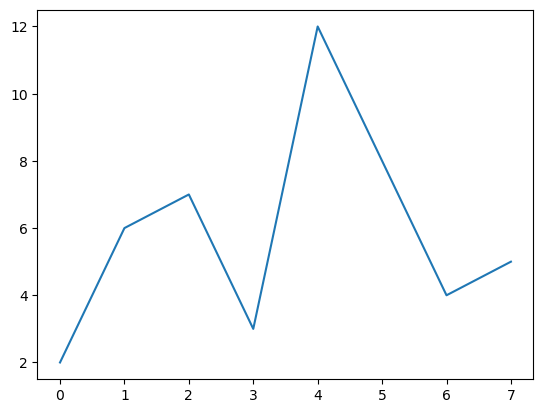

In [45]:
import matplotlib.pyplot as plt
import numpy as np

a = np.array([2, 6, 7, 3, 12, 8, 4, 5])
plt.plot(a)
plt.show()

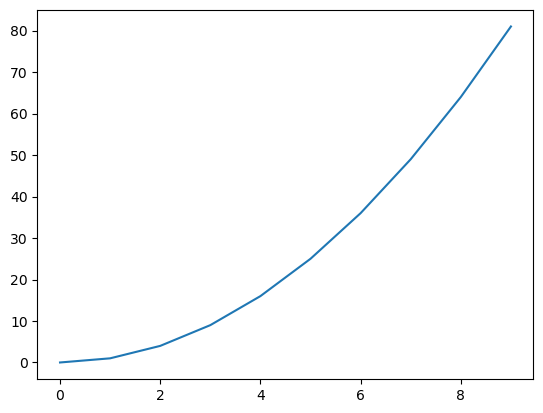

In [46]:
x = np.arange(10)
y = x ** 2
plt.plot(x, y)
plt.show()

## 3.2.3 color & style
**색상:** `b`(파), `g`(초), `r`(빨), `c`(청록), `m`(자홍), `y`(노), `k`(검), `w`(흰)
**선:** `-`(실선) `--`(파선) `-.`(파선+점) `:`(점선)
**마커:** `.` `o` `^` `v` `s` `+` `x` `D`

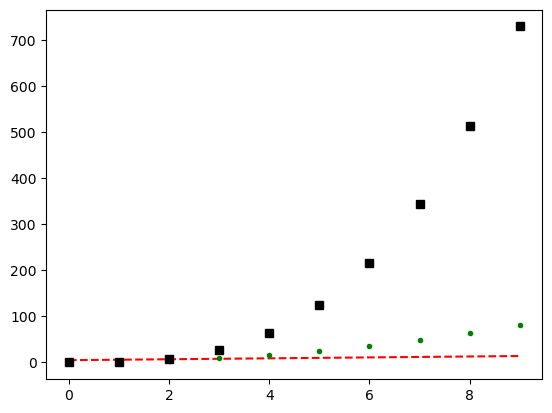

In [47]:
x = np.arange(10)
f1 = x + 5
f2 = x ** 2
f3 = x ** 3
plt.plot(x, f1, 'r--')   # 빨간 파선
plt.plot(x, f2, 'g.')    # 초록 점
plt.plot(x, f3, 'ks')    # 검정 사각형
plt.show()

## 3.2.4 subplot
`plt.subplot(행, 열, 번호)` - 여러 그래프를 한 화면에

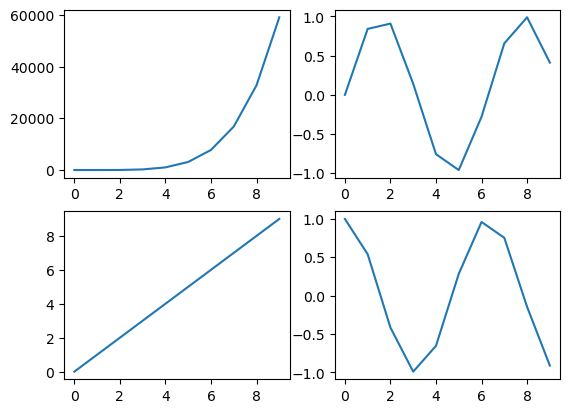

In [48]:
x = np.arange(10)
plt.subplot(2, 2, 1); plt.plot(x, x**5)
plt.subplot(2, 2, 2); plt.plot(x, np.sin(x))
plt.subplot(2, 2, 3); plt.plot(x, x)
plt.subplot(2, 2, 4); plt.plot(x, np.cos(x))
plt.show()

## 3.2.5 이미지 표시
- OpenCV 이미지는 BGR -> `img[:,:,::-1]` 로 RGB 변환 후 `plt.imshow()`
- `plt.xticks([])`, `plt.yticks([])`: 축 눈금 제거

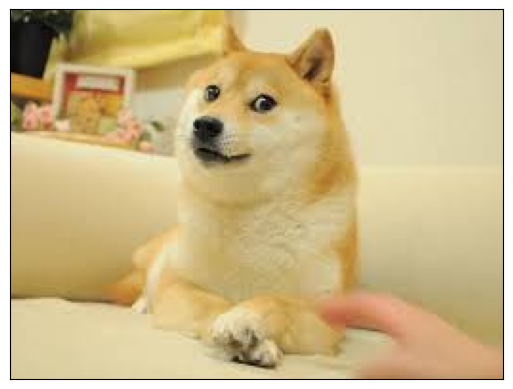

In [49]:
import cv2
from matplotlib import pyplot as plt

img = cv2.imread('../Data/images/doge.jpg')
img_rgb = img[:, :, ::-1]   # BGR -> RGB
plt.imshow(img_rgb)
plt.xticks([])
plt.yticks([])
plt.show()

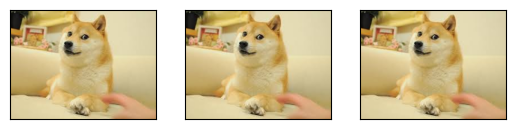

In [50]:
# 여러 이미지 subplot 출력
img1 = cv2.imread('../Data/images/doge.jpg')
img2 = cv2.imread('../Data/images/doge.jpg')
img3 = cv2.imread('../Data/images/doge.jpg')

plt.subplot(1,3,1); plt.imshow(img1[:,:,::-1]); plt.xticks([]); plt.yticks([])
plt.subplot(1,3,2); plt.imshow(img2[:,:,::-1]); plt.xticks([]); plt.yticks([])
plt.subplot(1,3,3); plt.imshow(img3[:,:,::-1]); plt.xticks([]); plt.yticks([])
plt.show()